# Inflation Base Effects: Portfolio Experiment

I test whether positioning for the predictable departure of a large CPI print
earns positive sovereign bond returns. The primary portfolio uses an NSA
inflation signal, exponentially weighted scoring, and duration-neutral sizing
across the US, Germany, the UK, and Canada.

I compare the primary result with seasonal normalization and rank/DV01 sizing,
then examine exposures, country contributions, costs, benchmark-adjusted returns,
and stability through time. All calculations use the frozen inputs described
in [the data notebook](01_data_and_mechanism.ipynb).
[The appendix](03_sensitivity_and_measurement.ipynb) covers parameter and
measurement sensitivity.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

from inflation_base_effects.data import REPO_ROOT, compute_base_effect, load_cpi, load_yields
from inflation_base_effects.evaluation import (
    EmpPerfStats,
    regime_stability,
    rolling_hac_mean,
)
from inflation_base_effects.portfolio import (
    compute_bond_returns,
    ewmacov,
    full_backtest,
    rank_dv01_holdings,
)
from inflation_base_effects.research import (
    benchmark_regression,
    comparison_table,
    constraint_summary,
    leave_one_out,
    performance_summary,
    portfolio_attribution,
    realized_turnover,
)
from inflation_base_effects.signals import calc_month_of_year_signal, calc_signal_from_base_effect

pd.options.display.float_format = "{:.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")
FIGURES = Path(REPO_ROOT) / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Portfolio construction

| Stage | Definition | Interpretation |
|---|---|---|
| Departing print | $m_{t-12}$ from NSA log CPI | A large print puts downward pressure on annual inflation |
| Score | Six-month EWM z-score, capped at $\pm2$ | Positive scores favour long duration |
| Implementation | Delay the score by one month | Monthly information ordering |
| Formation | Covariance and yields through month $t$ | Inputs available at portfolio formation |
| Earnings | $r^p_{t+1}=h_t' r_{t+1}$ | Prior-period holdings earn the subsequent return |

I score the twelve-month-old print, delay the score by one month, and use
prior-period holdings to calculate returns. The EWM moments include the
available departing print. I exclude earning months that lack required asset
returns or prior holdings.

### Return approximation and sizing

I approximate monthly bond returns as carry plus the first-order price response
to a yield change:

$$r_{i,t}\approx y_{i,t-1}/12-D_{i,t-1}(y_{i,t}-y_{i,t-1}).$$

Yields in this equation are decimal annual yields; I convert the percent units
in the source data. Duration follows the continuous par-bond formula, including
its zero-yield limit. The appendix sets out the formula and its behaviour at
low and negative yields.

I map scores to assumed expected returns and solve

$$\alpha_{i,t}=0.05\,\widehat\sigma_{i,t}z_{i,t},\qquad
\max_h\;\alpha_t'h-\tfrac12 h'\Sigma_t h.$$

The information coefficient of 0.05 is a sizing assumption. I blend 12- and
36-month EWMA covariance estimates with weights 0.7 and 0.3, and add a small
diagonal ridge inside the optimization for numerical stability. The constraints
are $D_t'h=0$, $\sum_i|h_i|\le2$, $|h_i|\le0.5$, and annual forecast volatility
at most 10%. SCS solves these constraints jointly. Failed solves produce flat
holdings; I report their count with the exposure diagnostics.

In [2]:
headline_nsa = load_cpi()
yields_monthly = load_yields()
bond_returns, bond_duration = compute_bond_returns(yields_monthly)
rolling_off = compute_base_effect(headline_nsa)
last_return_date = bond_returns.dropna(how="all").index[-1]

primary_score = calc_signal_from_base_effect(rolling_off, last_return_date, hl=6, implag=1).dropna(
    how="any"
)
month_score = calc_month_of_year_signal(
    rolling_off, last_return_date, min_history=5, implag=1
).dropna(how="any")

covariance = ewmacov(bond_returns.dropna(), halflife=(12, 36), shrinkage_factor=0.3)
primary_h, _, primary_perf, diagnostics = full_backtest(
    primary_score, covariance, bond_returns, bond_duration
)
month_h, _, month_perf, _ = full_backtest(month_score, covariance, bond_returns, bond_duration)
rank_h = rank_dv01_holdings(primary_score, bond_duration, gross_exposure=1.0)
rank_perf = EmpPerfStats(rank_h, bond_returns)

## 2. Performance

I evaluate three specifications. The primary optimizer and rank/DV01 portfolio
share the NSA/EWM score. The seasonal variant standardizes each calendar month
against its own earlier observations, with a five-observation warm-up. I report
each available history and a common-date comparison to separate specification
differences from sample coverage.

The rank portfolio uses unit gross exposure, while the optimizer can use up to
two. I report volatility alongside returns because the risk levels differ.
Return/volatility uses the annualized arithmetic mean without a cash or benchmark
adjustment. The HAC confidence intervals concern that mean.

In [3]:
strategy_returns = {
    "Primary NSA/EWM optimizer": primary_perf.port_ret,
    "Expanding month-of-year optimizer": month_perf.port_ret,
    "Primary signal rank/DV01": rank_perf.port_ret,
}
strategy_holdings = dict(zip(strategy_returns, [primary_h, month_h, rank_h], strict=True))
full_history = comparison_table(strategy_returns, strategy_holdings, common=False)
common_history = comparison_table(strategy_returns, strategy_holdings, common=True)
display(full_history)
display(common_history)

,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Primary NSA/EWM optimizer,400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,1.9805,1991-09,2024-12
Expanding month-of-year optimizer,345.0000,0.0054,0.0284,0.1916,1.1815,0.2374,-0.0036,0.0145,5.0000,-0.1036,1.8304,1996-04,2024-12
Primary signal rank/DV01,400.0000,-0.0002,0.0142,-0.0148,-0.0901,0.9282,-0.0048,0.0043,5.0000,-0.1112,1.0066,1991-09,2024-12


,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Primary NSA/EWM optimizer,345.0000,-0.0001,0.0257,-0.0026,-0.0152,0.9879,-0.0087,0.0085,5.0000,-0.1330,1.9882,1996-04,2024-12
Expanding month-of-year optimizer,345.0000,0.0054,0.0284,0.1916,1.1815,0.2374,-0.0036,0.0145,5.0000,-0.1036,1.8304,1996-04,2024-12
Primary signal rank/DV01,345.0000,-0.0003,0.0131,-0.0260,-0.1469,0.8832,-0.0049,0.0042,5.0000,-0.0852,1.0212,1996-04,2024-12


The primary annual mean is approximately -0.08% over its full history, with a
95% interval of -0.92% to +0.77%. On common dates, the primary mean is about
-0.01% and the seasonal mean is +0.54%; neither differs significantly from zero.

I express weights as reference-notional exposures and sum monthly returns to
calculate cumulative value added. Drawdown is the decline from the peak of that
additive P&L, including the initial zero level. Turnover measures absolute
notional traded, including initial funding and excluding final liquidation
and wealth-drift adjustments.

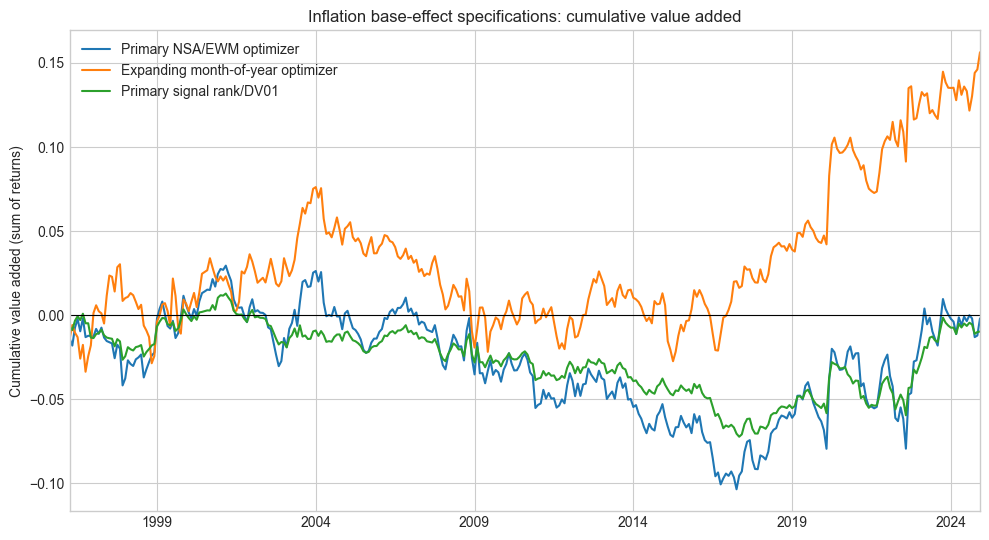

In [4]:
comparison_returns = pd.concat(
    {
        "Primary NSA/EWM optimizer": primary_perf.port_ret,
        "Expanding month-of-year optimizer": month_perf.port_ret,
        "Primary signal rank/DV01": rank_perf.port_ret,
    },
    axis=1,
    join="inner",
)
comparison_va = comparison_returns.cumsum()

fig, ax = plt.subplots(figsize=(10, 5.5))
comparison_va.plot(ax=ax, linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Inflation base-effect specifications: cumulative value added")
ax.set_ylabel("Cumulative value added (sum of returns)")
ax.set_xlabel("")
ax.legend(frameon=False)
fig.tight_layout()

figure_path = Path(REPO_ROOT) / "docs" / "figures" / "strategy_summary.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

## 3. Exposures and constraints

With four assets capped at 0.5, the position limits imply the gross cap of 2.
I report which limits bind alongside forecast volatility and duration residuals.
Net notional can differ from zero.

Duration neutrality offsets a common parallel yield shock in the proxy units.
Country-specific yield movements, currency exposure, credit, and financing
remain outside that constraint.

,value
months,401.0000
failed,0.0000
max_duration_residual,0.0000
max_gross,2.0000
max_position,0.5000
max_forecast_vol,0.0554
position_binding_pct,99.7506
gross_binding_pct,2.2444
vol_binding_pct,0.0000


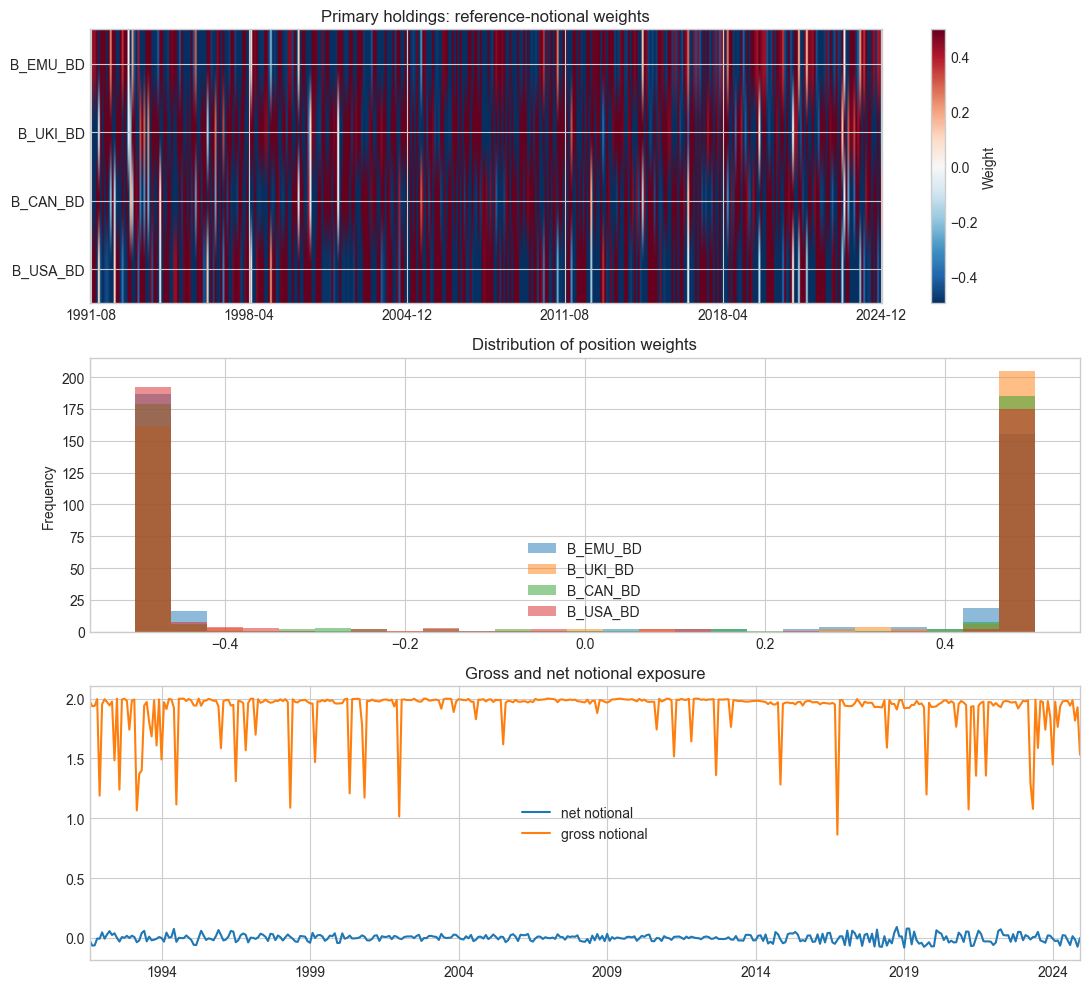

In [5]:
display(constraint_summary(diagnostics).to_frame("value"))
assert diagnostics.duration_residual.abs().max() < 1e-3
assert diagnostics.gross_exposure.max() <= 2.001
assert diagnostics.max_position.max() <= 0.501
assert np.sqrt(12 * diagnostics.ex_ante_var.max()) <= 0.101
fig, axes = plt.subplots(3, 1, figsize=(11, 10))
image = axes[0].imshow(primary_h.T, aspect="auto", cmap="RdBu_r", vmin=-0.5, vmax=0.5)
axes[0].set_yticks(range(len(primary_h.columns)), primary_h.columns)
ticks = np.linspace(0, len(primary_h) - 1, 6).astype(int)
axes[0].set_xticks(ticks, primary_h.index[ticks].strftime("%Y-%m"))
axes[0].set_title("Primary holdings: reference-notional weights")
fig.colorbar(image, ax=axes[0], label="Weight")
primary_h.plot.hist(ax=axes[1], bins=25, alpha=0.5)
axes[1].set_title("Distribution of position weights")
pd.DataFrame(
    {"net notional": primary_h.sum(axis=1), "gross notional": primary_h.abs().sum(axis=1)}
).plot(ax=axes[2])
axes[2].set_title("Gross and net notional exposure")
fig.tight_layout()
plt.show()

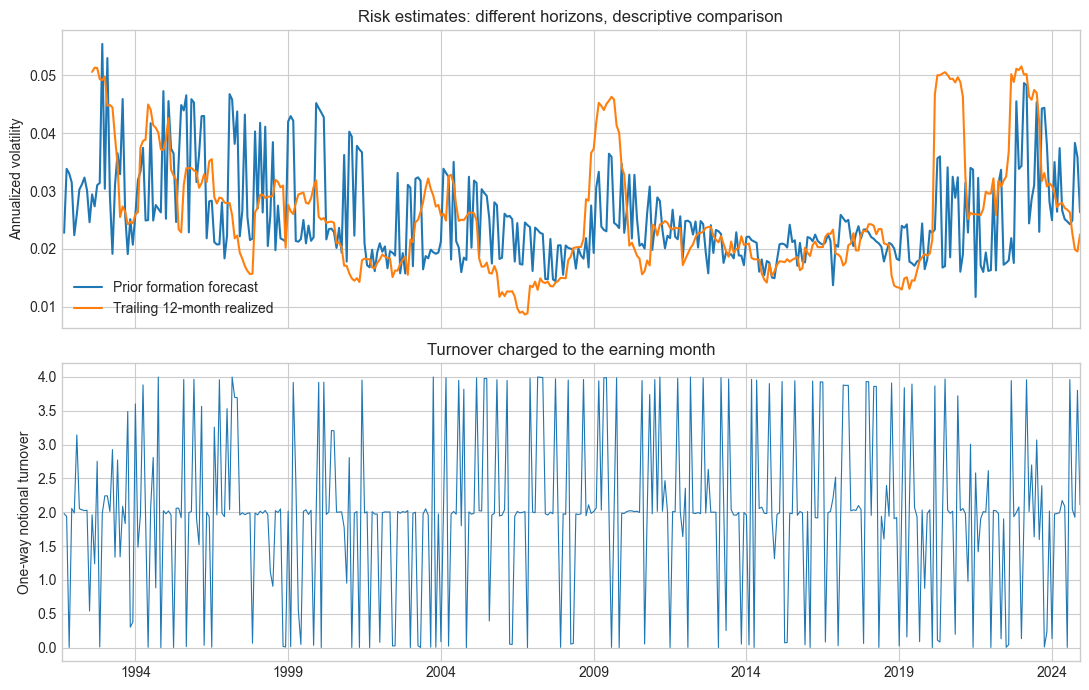

In [6]:
forecast_vol = np.sqrt(12 * diagnostics.ex_ante_var).shift(1)
realized_vol = primary_perf.port_ret.rolling(12).std() * np.sqrt(12)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
pd.concat(
    {"Prior formation forecast": forecast_vol, "Trailing 12-month realized": realized_vol}, axis=1
).plot(ax=axes[0])
axes[0].set(
    ylabel="Annualized volatility",
    title="Risk estimates: different horizons, descriptive comparison",
)
realized_turnover(primary_h).plot(
    ax=axes[1], title="Turnover charged to the earning month", linewidth=0.8
)
axes[1].set_ylabel("One-way notional turnover")
fig.tight_layout()
plt.show()

The position cap binds in almost every formation month, and the 10% volatility
ceiling never binds. Position limits therefore determine much of the implemented
risk. The volatility chart compares a one-month forecast with a trailing
twelve-month realized estimate; the different horizons limit its use as a
forecast-calibration test.

## 4. Return attribution

I calculate country contributions using the same prior-period holdings and
complete-case months as the portfolio return. Carry and yield-change contributions
sum to total P&L.

I also split returns into the contribution of average holdings (tilt) and
deviations from those holdings (timing). Both components are additive in return
units. The average holding uses the full sample, so this is an ex-post
decomposition. Return/volatility ratios do not add across the components.

,annual_mean_contribution,monthly_std_contribution
B_EMU_BD,0.0020,0.0072
B_UKI_BD,0.0059,0.0085
B_CAN_BD,-0.0020,0.0082
B_USA_BD,-0.0066,0.0091


,annual_mean_contribution
carry,0.0003
yield_change,-0.0010
total,-0.0008
tilt,0.0004
timing,-0.0012


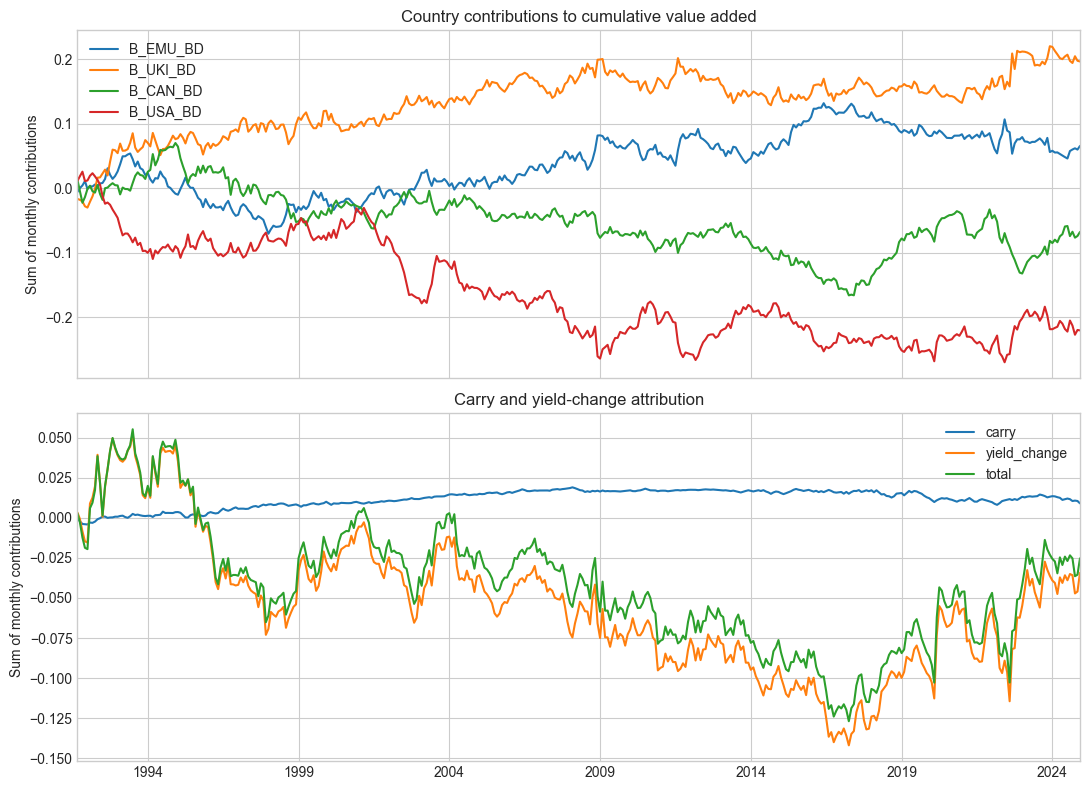

In [7]:
country_contributions, components = portfolio_attribution(primary_h, yields_monthly)
np.testing.assert_allclose(country_contributions.sum(axis=1), primary_perf.port_ret)
np.testing.assert_allclose(components.carry + components.yield_change, primary_perf.port_ret)
display(
    pd.DataFrame(
        {
            "annual_mean_contribution": 12 * country_contributions.mean(),
            "monthly_std_contribution": country_contributions.std(),
        }
    )
)
display((12 * components.mean()).to_frame("annual_mean_contribution"))
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
country_contributions.cumsum().plot(
    ax=axes[0], title="Country contributions to cumulative value added"
)
components[["carry", "yield_change", "total"]].cumsum().plot(
    ax=axes[1], title="Carry and yield-change attribution"
)
for ax in axes:
    ax.set_ylabel("Sum of monthly contributions")
fig.tight_layout()
fig.savefig(FIGURES / "portfolio_attribution.png", dpi=180, bbox_inches="tight")
plt.show()

### Country concentration

The UK contributes about +0.59% per year and the US about -0.66% in the
four-country portfolio, with Canada also negative. These contributions depend
on the joint portfolio's holdings.

To test concentration, I exclude each country in turn and re-estimate scores,
covariance, alpha, and holdings for the three-country universe. I retain the
signal definition and constraint values, then compare the portfolios on common
dates. Subtracting a country contribution alone would generally break duration
neutrality; re-estimation allows the remaining positions to adjust.

In [8]:
excluded = leave_one_out(headline_nsa, yields_monthly)
loo_returns = {
    "All four countries": primary_perf.port_ret,
    **{name: exp.returns for name, exp in excluded.items()},
}
loo_holdings = {
    "All four countries": primary_h,
    **{name: exp.holdings for name, exp in excluded.items()},
}
display(comparison_table(loo_returns, loo_holdings))
loo_constraints = pd.DataFrame(
    {name: constraint_summary(exp.diagnostics) for name, exp in excluded.items()}
).T
display(loo_constraints)
assert (loo_constraints.max_duration_residual < 1e-3).all()
assert (loo_constraints.max_position <= 0.501).all()
assert (loo_constraints.max_gross <= 2.001).all()
assert (loo_constraints.max_forecast_vol <= 0.101).all()

,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
All four countries,400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,1.9805,1991-09,2024-12
Without B_EMU_BD,400.0000,-0.0006,0.0223,-0.0269,-0.1615,0.8717,-0.0079,0.0067,5.0000,-0.1262,1.3329,1991-09,2024-12
Without B_UKI_BD,400.0000,-0.0013,0.0207,-0.0624,-0.3725,0.7095,-0.0081,0.0055,5.0000,-0.1715,1.3481,1991-09,2024-12
Without B_CAN_BD,400.0000,-0.0015,0.0195,-0.0765,-0.4996,0.6173,-0.0073,0.0044,5.0000,-0.1232,1.2446,1991-09,2024-12
Without B_USA_BD,400.0000,0.0020,0.0195,0.1009,0.6546,0.5127,-0.0039,0.0079,5.0000,-0.0858,1.3862,1991-09,2024-12


,months,failed,max_duration_residual,max_gross,max_position,max_forecast_vol,position_binding_pct,gross_binding_pct,vol_binding_pct
Without B_EMU_BD,401.0000,0.0000,0.0000,1.0594,0.5000,0.0376,99.7506,0.0000,0.0000
Without B_UKI_BD,401.0000,0.0000,0.0000,1.0722,0.5000,0.0319,99.7506,0.0000,0.0000
Without B_CAN_BD,401.0000,0.0000,0.0000,1.0689,0.5000,0.0327,99.7506,0.0000,0.0000
Without B_USA_BD,401.0000,0.0000,0.0000,1.0537,0.5000,0.0377,99.5012,0.0000,0.0000


## 5. Benchmark comparison

I compare the strategy with a monthly equal-weight long-only portfolio of the
same four synthetic bond returns. I align monthly returns directly and estimate
$r^p_t=a+b r^{EW}_t+u_t$ with HAC errors. The intercept measures performance
conditional on this benchmark. The benchmark has positive duration, while the
strategy is duration-neutral.

I also calculate a fixed 50/50 combination to examine the effect of adding the
signal to bond exposure. Both return series omit financing, cash returns, and
FX hedging.

In [9]:
benchmark = bond_returns.dropna().mean(axis=1).rename("Equal-weight long-only proxy")
benchmark_frame = pd.concat(
    {"Primary": primary_perf.port_ret, "Bond benchmark": benchmark}, axis=1
).dropna()
benchmark_frame["Fixed 50/50 combination"] = benchmark_frame.mean(axis=1)
display(comparison_table({name: series for name, series in benchmark_frame.items()}))
display(benchmark_frame.corr())
display(benchmark_regression(primary_perf.port_ret, benchmark).to_frame("estimate"))

,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Primary,400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
Bond benchmark,400.0000,0.0505,0.0518,0.9743,4.3386,0.0000,0.0277,0.0733,5.0000,-0.2931,NaN,1991-09,2024-12
Fixed 50/50 combination,400.0000,0.0249,0.0286,0.8702,4.1051,0.0000,0.0130,0.0367,5.0000,-0.1458,NaN,1991-09,2024-12


,Primary,Bond benchmark,Fixed 50/50 combination
Primary,1.0000,-0.0617,0.4253
Bond benchmark,-0.0617,1.0000,0.8770
Fixed 50/50 combination,0.4253,0.8770,1.0000


,estimate
N,400.0000
ann_intercept,0.0009
CI lower,-0.0090
CI upper,0.0108
HAC t,0.1775
p,0.8591
beta,-0.0328
correlation,-0.0617
R2,0.0038
HAC lags,5.0000


I find little correlation with the long-only benchmark and an imprecise
benchmark-adjusted intercept. The fixed combination does not improve the
benchmark's return/volatility ratio. In this sample, diversification from the
signal does not compensate for its weak mean return.

## 6. Transaction costs

I deduct 1, 3, 5, and 10 basis points per one-way unit of notional turnover.
Trades forming holdings in month $t$ are charged alongside the first earning
month, $t+1$. With mean monthly turnover close to two units of notional,
a 1 bp charge costs roughly 0.24 percentage points per year.

These fixed-cost scenarios omit bid/ask dynamics, market impact, financing,
collateral, futures rolls, currency hedges, and final liquidation.

In [10]:
cost_turnover = realized_turnover(primary_h).reindex(primary_perf.port_ret.index)
cost_table = pd.DataFrame(
    {
        bps: performance_summary(primary_perf.port_ret - cost_turnover * bps / 10000, cost_turnover)
        for bps in [0, 1, 3, 5, 10]
    }
).T
cost_table.index.name = "One-way cost (bp)"
display(cost_table)

,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
One-way cost (bp),,,,,,,,,,,,,
0,400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,1.9805,1991-09,2024-12
1,400.0000,-0.0031,0.0275,-0.1140,-0.7254,0.4682,-0.0116,0.0053,5.0000,-0.2395,1.9805,1991-09,2024-12
3,400.0000,-0.0079,0.0275,-0.2867,-1.8192,0.0689,-0.0164,0.0006,5.0000,-0.3662,1.9805,1991-09,2024-12
5,400.0000,-0.0126,0.0275,-0.4589,-2.9030,0.0037,-0.0212,-0.0041,5.0000,-0.5079,1.9805,1991-09,2024-12
10,400.0000,-0.0245,0.0277,-0.8842,-5.5518,0.0000,-0.0332,-0.0159,5.0000,-0.8632,1.9805,1991-09,2024-12


## 7. Temporal stability

I compare returns before and after January 2010 using the primary score in
both the optimizer and rank/DV01 portfolios. A regression on a post-period
indicator estimates the change in mean return, with Newey-West inference.
The seasonal variant is assessed separately in the specification comparison.

The date divides the sample for a descriptive stability check. It does not
identify a publication date, investor adoption, or a causal change in pricing.

In [11]:
STABILITY_SPLIT = pd.Timestamp("2010-01-01")
optimizer_stability = regime_stability(primary_perf.port_ret, STABILITY_SPLIT)
rank_stability = regime_stability(rank_perf.port_ret, STABILITY_SPLIT)

stability_table = pd.concat(
    {
        "Primary NSA/EWM optimizer": optimizer_stability,
        "Primary signal rank/DV01": rank_stability,
    },
    names=["implementation", "period"],
)
display(stability_table)

N  ann_return  ann_vol  \
implementation            period                                         
Primary NSA/EWM optimizer pre            220.0000     -0.0030   0.0280   
                          post           180.0000      0.0020   0.0270   
                          post_minus_pre 400.0000      0.0051      NaN   
Primary signal rank/DV01  pre            220.0000     -0.0013   0.0145   
                          post           180.0000      0.0011   0.0138   
                          post_minus_pre 400.0000      0.0025      NaN   

                                          return_to_vol  NW t-stat  \
implementation            period                                     
Primary NSA/EWM optimizer pre                   -0.1088    -0.5182   
                          post                   0.0756     0.2985   
                          post_minus_pre            NaN     0.5855   
Primary signal rank/DV01  pre                   -0.0910    -0.4256   
                          post                   0.0827     0.3124   
                          post_minus_pre            NaN     0.5233   

                                          NW p-value  CI 95% lower  \
implementation            period                                     
Primary NSA/EWM optimizer pre                 0.6043       -0.0146   
                          post                0.7653       -0.0113   
                          post_minus_pre      0.5582       -0.0119   
Primary signal rank/DV01  pre                 0.6704       -0.0074   
                          post                0.7547       -0.0060   
                          post_minus_pre      0.6008       -0.0068   

                                          CI 95% upper  NW maxlags  
implementation            period                                    
Primary NSA/EWM optimizer pre                   0.0085      4.0000  
                          post                  0.0154      4.0000  
                          post_minus_pre        0.0221      5.0000  
Primary signal rank/DV01  pre                   0.0047      4.0000  
                          post                  0.0083      4.0000  
                          post_minus_pre        0.0117      5.0000

I also estimate trailing 120-month means and HAC confidence intervals. The
windows overlap, so the estimates describe performance through time without
providing independent tests of predictability.

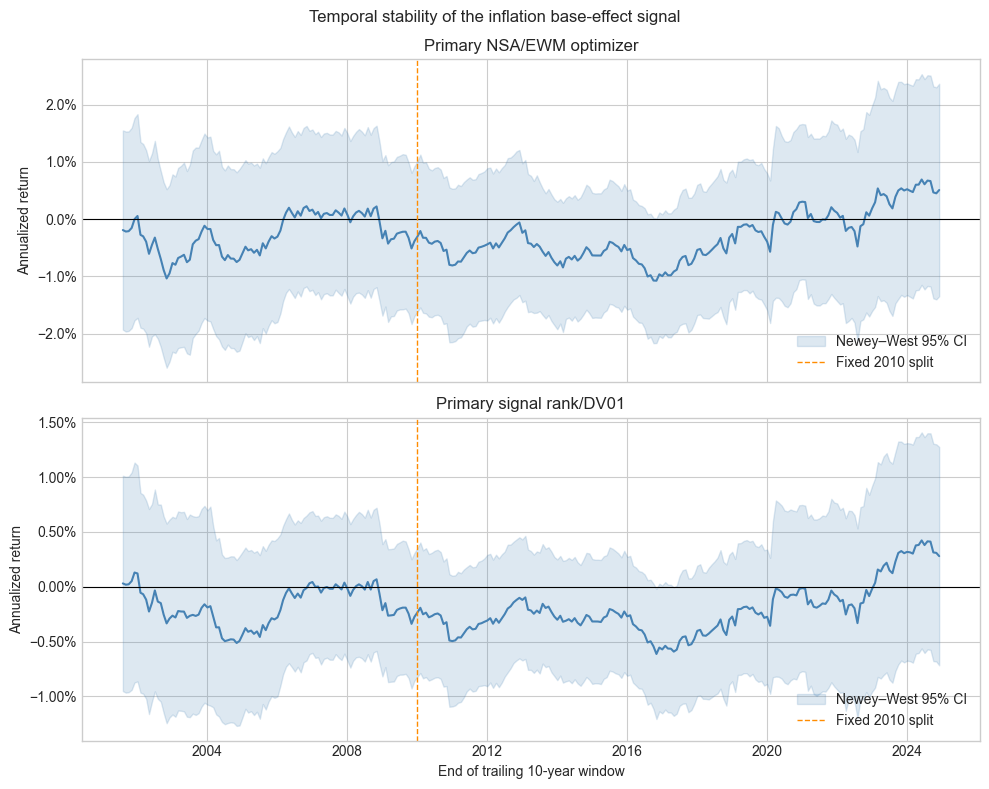

In [12]:
rolling_primary = rolling_hac_mean(primary_perf.port_ret, window=120)
rolling_rank = rolling_hac_mean(rank_perf.port_ret, window=120)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for ax, (label, rolling) in zip(
    axes,
    [
        ("Primary NSA/EWM optimizer", rolling_primary),
        ("Primary signal rank/DV01", rolling_rank),
    ],
    strict=True,
):
    ax.plot(rolling.index, rolling["ann_return"], color="steelblue", linewidth=1.5)
    ax.fill_between(
        rolling.index,
        rolling["CI 95% lower"].to_numpy(),
        rolling["CI 95% upper"].to_numpy(),
        color="steelblue",
        alpha=0.18,
        label="Newey–West 95% CI",
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(
        STABILITY_SPLIT,
        color="darkorange",
        linestyle="--",
        linewidth=1.0,
        label="Fixed 2010 split",
    )
    ax.set_title(label)
    ax.set_ylabel("Annualized return")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(frameon=False, loc="lower right")
axes[-1].set_xlabel("End of trailing 10-year window")
fig.suptitle("Temporal stability of the inflation base-effect signal")
fig.tight_layout()

stability_figure_path = Path(REPO_ROOT) / "docs" / "figures" / "temporal_stability.png"
fig.savefig(stability_figure_path, dpi=180, bbox_inches="tight")
plt.show()

In [13]:
changes = stability_table.xs("post_minus_pre", level="period")
decay_evidence = (changes["ann_return"] < 0) & (changes["NW p-value"] < 0.05)
decay_assessment = pd.DataFrame(
    {
        "annualized post-minus-pre change": changes["ann_return"],
        "NW p-value": changes["NW p-value"],
        "evidence consistent with decay": decay_evidence,
    }
)
display(decay_assessment)

if decay_evidence.all():
    print("I find a statistically significant decline in both portfolio implementations.")
else:
    print("I find no evidence that positive alpha subsequently decayed.")

,annualized post-minus-pre change,NW p-value,evidence consistent with decay
implementation,,,
Primary NSA/EWM optimizer,0.0051,0.5582,False
Primary signal rank/DV01,0.0025,0.6008,False


I find no evidence that positive alpha subsequently decayed.


## 8. Findings and limitations

I find little evidence that the base-effect signal predicts positive sovereign
bond returns in this four-country sample. The primary mean is slightly negative,
the confidence interval is wide, and costs reduce performance further. The
seasonal variant has a positive but statistically insignificant mean. Neither
the benchmark comparison nor the pre/post-2010 test establishes positive alpha
or subsequent decay.

The study uses synthetic returns based on monthly-average yields. Those inputs
omit convexity, instrument-specific cash flows, financing, and FX hedges, and
they cannot measure announcement-day adjustment. The US month-end comparison
in the appendix shows the sensitivity to yield sampling while retaining the
other countries' monthly-average inputs.

I use current-vintage data and a monthly information convention. A point-in-time
test would also require historical vintages and release calendars. The small
country universe, binding position caps, and assumed information coefficient
further limit generality.

The specification comparisons and 2010 split use already-examined historical
data. I treat them as exploratory and have no untouched holdout sample. The
intervals admit economically relevant losses and gains; more precise inference
would require better return measurement and independent validation data.